<a href="https://colab.research.google.com/github/Aarjav8055/ML-LAB/blob/main/LAB8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

K-Means Clustering Done


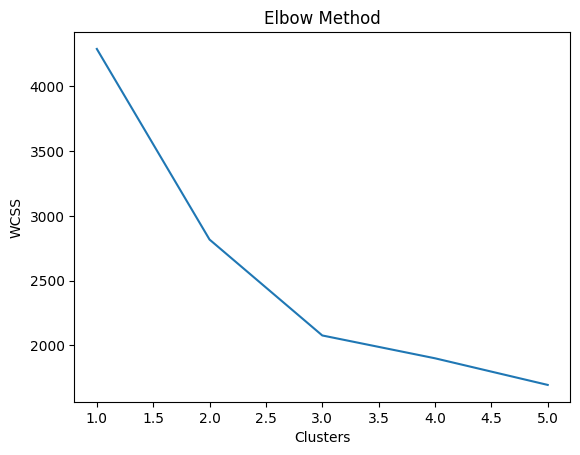

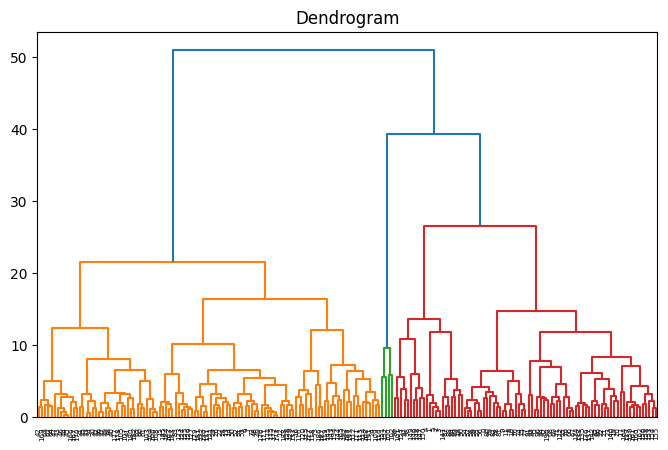

In [1]:
# =========================================
# Import Libraries
# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage

# =========================================
# Load Dataset
# =========================================
df = pd.read_csv("/content/parkinsons.data")

# Drop non-numeric column
df.drop("name", axis=1, inplace=True)

# Use features only
X = df.drop("status", axis=1)

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================================
# K-Means Clustering
# =========================================
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

print("K-Means Clustering Done")

# =========================================
# Elbow Method
# =========================================
wcss = []
for i in range(1, 6):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 6), wcss)
plt.title("Elbow Method")
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.show()

# =========================================
# Hierarchical Clustering
# =========================================
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(8,5))
dendrogram(linked)
plt.title("Dendrogram")
plt.show()
